# Data Generator Notebook

This notebook generates (non-)Gaussian fields using CAMB and saves them in a .npy file and as tensorboard datasets.

Base code was taken from Thomas

Modifications by Brandon

In [1]:
# %load_ext autoreload
# %autoreload 2

import os
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm import tqdm

from DensityFields import DensityField2D

import os
import numpy as np
from typing import Literal
from joblib import Parallel, delayed
from logging import CRITICAL, DEBUG, INFO, WARNING, ERROR, FATAL

from DensityFields import DensityField2D
from numpy2dataset import save_numpy_to_tf_dataset
from functools import partial

2023-04-11 16:47:29.144836: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-04-11 16:47:31.225884: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2023-04-11 16:47:31.225944: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2023-04-11 16:47:39.290331: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2023-

## Functions

In [2]:
def _make_map(camb_helper, box_size, grid, cosmo, log_level, fnl, seed=None): #box_size, grid, k_cut_low=None,k_cut_high=None):
    base_field = DensityField2D(box_size, grid, camb_obj=camb_helper, cosmo_params=cosmo, log_level=log_level)
    base_field.GenerateCAMBField(fnl=fnl,seed=seed)
    return base_field.r_delta / base_field.r_delta.std()

def _save(dir, filename, maps):
    if not os.path.exists(dir): os.makedirs(dir)
    
    print(f'Saving {dir}/{filename}...', end=' ')
    with open(f'{dir}/{filename}', 'wb') as f:
        np.save(f, maps)
    print('Done!')

def run_simulations(data_dir, name, num_sim, save_steps, box_size, grid, fnls, 
                    force_fnl=None, n_jobs=-1, k_cut_low=None, k_cut_high=None, 
                    log_level=WARNING, cosmo=None, verbose=False):
    print('Generating base field...')
    base_field = DensityField2D(box_size, grid, cosmo_params=cosmo, log_level=log_level)      
    make_map = partial(_make_map, base_field.camb, box_size, grid, cosmo, log_level) 
    print('Done!')   
    
    for i in range(0, num_sim, save_steps):
        if verbose: print(f'Generating maps {i} to {i + save_steps} out of {num_sim} for {name}...')
        maps_chunk = Parallel(n_jobs=n_jobs, verbose=1)([
            delayed(make_map)( fnl if force_fnl is None else force_fnl ) for fnl in fnls[i:min(i + save_steps, num_sim)]
        ])
        if verbose: print('Done!')
        _save(data_dir, f'{name}_{i}-{i + save_steps}.npy', maps_chunk)

def _bispectrum(camb_helper, box_size, grid, cosmo, log_level, fnl, seed=None):
    base_field = DensityField2D(box_size, grid, camb_obj=camb_helper, cosmo_params=cosmo, log_level=log_level)
    base_field.GenerateCAMBField(fnl=fnl,seed=seed)
    BBB = base_field.Bk(2.5,3,13, 'All')
    return BBB

def get_bispectrum(fnl, num_bispectra, box_size, grid, log_level=WARNING, cosmo=None):
    print('Generating base field for bispectrum...')
    base_field = DensityField2D(box_size, grid, cosmo_params=cosmo, log_level=log_level)      
    bispec = partial(_bispectrum, base_field.camb, box_size, grid, cosmo, log_level) 
    print('Done!') 
    
    return np.array(Parallel(n_jobs=-1, verbose=1)([delayed(bispec)(fnl) for i in range(num_bispectra)]))

## Test Generation

### Test Settings

In [3]:
## Cosmology settings (LCDM)
cosmo_params = {
    'h': 0.6711,
    'r': 0,
    'As': 2.13e-09,
    'A': 2*np.pi*np.pi*2.13e-09,
    'ns': 0.9624,
    'kpivot': 0.05,
    'z_recomb': 1090.48,
    'ombh2': 0.02233,
    'omch2': 0.1198,
    'tau': 0.0561,
    'lmax': 11000,
    'accuracy_boost': 4,
}

num_bispectra = 10**4
fnl_range=(-1000, 1000)
num_threads = -1 #for all cores
BoxSize = 1000.                     # Size of the periodic box in Mpc/h
grid = 256                          # Size of the grid

# needed values
kF = 2*np.pi / BoxSize              # Fundamental mode of the box
kNyq = kF * grid / 2                # Nyquist frequency of the grid

# Should we only generate the data, skipping tests and fisher forcasts?
run_test = True 

[2023-04-11 16:47:51,504 | DensityFields -            __init__()] | DEBUG : Initializing Density Field...
[2023-04-11 16:47:51,525 | CAMBHelper -            __init__()] | DEBUG : Setting up CAMB parameters object
[2023-04-11 16:47:51,609 | CAMBHelper -            __init__()] | DEBUG : Done! (Setting up CAMB parameters object)
[2023-04-11 16:47:51,610 | CAMBHelper -            __init__()] | DEBUG : Getting CAMB results...
[2023-04-11 16:48:38,304 | CAMBHelper -            __init__()] | DEBUG : CAMB results obtained!
[2023-04-11 16:48:38,306 | CAMBHelper - calculate_transfers()] | DEBUG : Getting transfer functions...
[2023-04-11 16:48:38,524 | CAMBHelper - calculate_transfers()] | DEBUG : Done! (Getting transfer functions)
[2023-04-11 16:48:38,525 | CAMBHelper - calculate_transfers()] | DEBUG : Interpolating transfer functions with cubic splines.
[2023-04-11 16:48:46,856 | CAMBHelper - calculate_transfers()] | DEBUG : Done!
[2023-04-11 16:48:46,957 | DensityFields -            __init__(

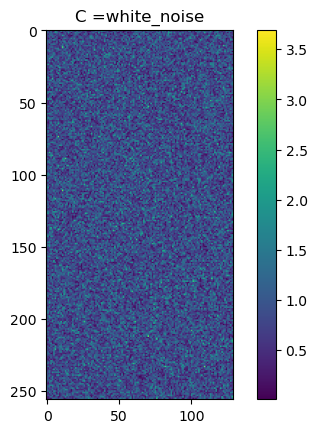

[2023-04-11 16:48:50,074 | DensityFields -   GenerateCAMBField()] | DEBUG : Applying primordial power spectrum...
[2023-04-11 16:48:50,091 | DensityFields -   GenerateCAMBField()] | DEBUG : done!


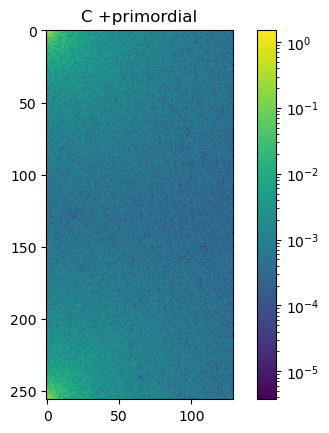

[2023-04-11 16:48:50,787 | DensityFields -   GenerateCAMBField()] | DEBUG : Making map non-Gaussian with fnl 1.0...


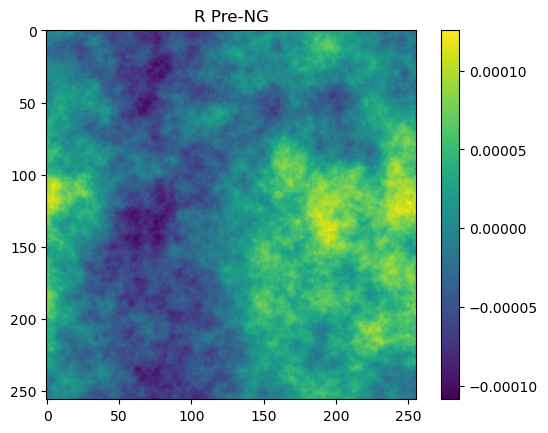

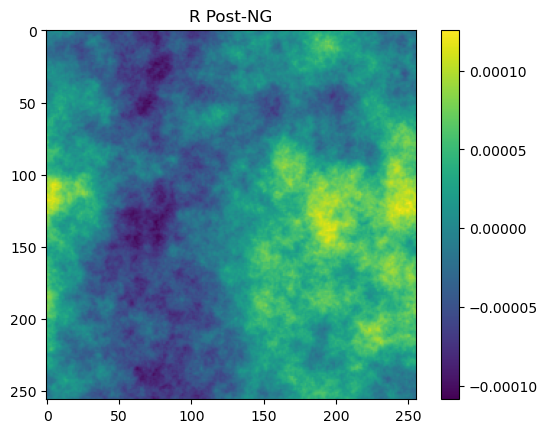

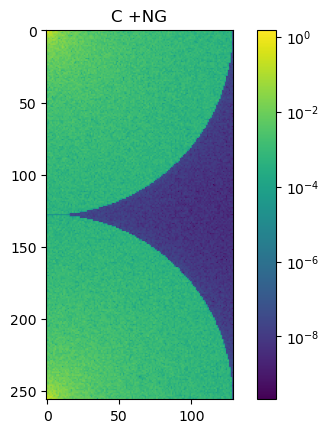

[2023-04-11 16:48:52,749 | DensityFields -   GenerateCAMBField()] | DEBUG : done!


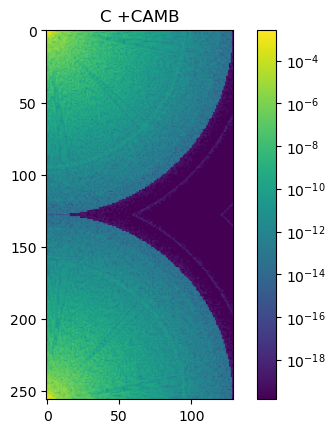

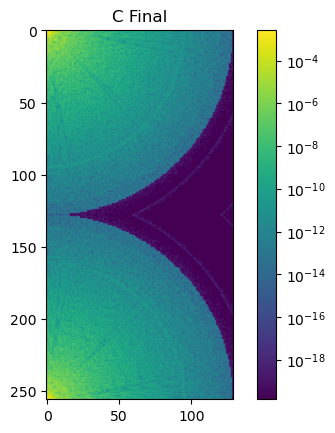

[2023-04-11 16:48:57,415 | DensityFields -   GenerateCAMBField()] | DEBUG : Fourier transforming to real space...


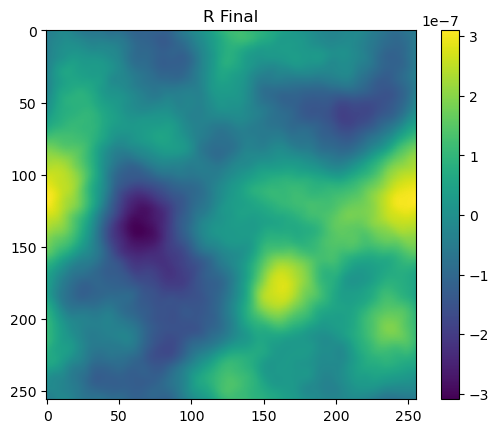

[2023-04-11 16:48:57,613 | DensityFields -   GenerateCAMBField()] | DEBUG : done!


In [4]:
if run_test:
    test_map = DensityField2D(BoxSize,grid,n_threads=1, cosmo_params=cosmo_params, log_level=DEBUG)
    test_field = test_map.GenerateCAMBField(fnl=1.,seed=0, debug_plots=True)

    test_map.camb.plot_cls()

In [ ]:
if run_test:
    FFT_map = DensityField2D(BoxSize,grid,n_threads=1, cosmo_params=cosmo_params)
    
    # Generate the same field but cut off at grid/3*kF (where FFT bispectrum measurements start to fail)
    FFT_map.GenerateCAMBField(0,fnl=1.,k_cut_high=grid/3*kF,seed=None)
    plt.imshow(FFT_map.r_delta)
    plt.title('density field with k_cut_high {}'.format(grid/3*kF))
    plt.show()

    kk, Pk, _ = FFT_map.Pk()
    plt.loglog(kk,Pk)
    plt.ylabel("$P(k)$ [Mpc/h]$^3$")
    plt.xlabel("$k$ [h/Mpc]")
    plt.show()

## Fisher Forecast

Computing Bispectra can be done as follows

In [ ]:
if run_test:
    # lets time how long to get the bispectrum
    df_base = DensityField2D(BoxSize, grid, n_threads=1, cosmo_params=cosmo_params)
    df_base.GenerateCAMBField(0,fnl=1.)
    
    # Compute the bispectrum in a given binning:
    BBB = FFT_map.Bk(2.5,3,13,'All')
    plt.semilogy(BBB[:,-2])
    plt.ylabel("$B(k)$ [Mpc/h]$^6$")
    plt.xlabel("triangle$_i$")
    print("kmax =",(BBB[-1,0]+1.5)*kF,grid/3*kF)

### Perform a Fisher forecast

We compute many bispectra with fixed amounts of pnG

In [ ]:
if run_test:
    BispecP = get_bispectrum(100, num_bispectra, box_size=BoxSize, grid=grid, cosmo=cosmo_params)
    BispecM = get_bispectrum(-100, num_bispectra, box_size=BoxSize, grid=grid, cosmo=cosmo_params)
    BispecG = get_bispectrum(0, num_bispectra, box_size=BoxSize, grid=grid, cosmo=cosmo_params)

We compute the covariance matrix and its inverse, corrected by the Hartlap factor

In [ ]:
if run_test:
    Cov = np.cov(BispecG[:,:,-2].T)

    hartlapfactor = (len(BispecG) - len(Cov) - 2) / (len(BispecG) - 1)
    Cov_Inv = np.linalg.inv(Cov)
    Cov_Inv *= hartlapfactor

    Cov = np.diag(np.diag(Cov))
    # Cov_Inv = np.linalg.inv(Cov)

    plt.semilogy(np.diag(Cov))
    print(hartlapfactor)

We compute the derivative of the bispectra with respect to $f_{\rm NL}$

In [ ]:
if run_test:
    dBdf = (BispecP.mean(0)[:,-2]-BispecM.mean(0)[:,-2])/200
    plt.semilogy(dBdf)
    plt.show()

### Then the Fisher information is given by $$F = \sum_{TT'} \frac{\partial B_T}{f_{\rm NL}} C^{-1}_{TT'} \frac{\partial B_{T'}}{f_{\rm NL}}$$ and the measurement error is $\sigma_{f_{\rm NL}} = F^{-1/2}$

In [ ]:
if run_test:
    FF = (dBdf.dot(Cov_Inv).dot(dBdf))
    sigma = FF**-.5
    print(sigma)

### One can also estimate $f_{\rm NL}$ from the generated bispectra: $$\hat{f}_{\rm NL} = F^{-1}\sum{TT'}\frac{\partial B_T}{f_{\rm NL}}C^{-1}_{TT'} B_{T'}$$ where $B_{T'}$ is a measured bispectrum

In [ ]:
if run_test:
    estimates_P = np.array([dBdf.dot(Cov_Inv).dot(BispecP[i,:,-2])/FF for i in tqdm(range(len(BispecP)))])
    estimates_M = np.array([dBdf.dot(Cov_Inv).dot(BispecM[i,:,-2])/FF for i in tqdm(range(len(BispecM)))])
    estimates_G = np.array([dBdf.dot(Cov_Inv).dot(BispecG[i,:,-2])/FF for i in tqdm(range(len(BispecG)))])

In [ ]:
if run_test: 
    print(estimates_P.mean(), estimates_M.mean(), estimates_G.mean())

In [ ]:
if run_test:
    print(estimates_P.std(), estimates_M.std(), estimates_G.std())

In [ ]:
if run_test:
    plt.hist(estimates_P,bins=100)
    plt.hist(estimates_G,bins=100)
    plt.hist(estimates_M,bins=100)
    plt.legend()
    plt.show()

In [ ]:
if run_test:
    plt.plot(BispecP.mean(0)[:,-2]*BispecP[0,:,:3].prod(1)*kF**3)
    plt.plot(BispecM.mean(0)[:,-2]*BispecM[0,:,:3].prod(1)*kF**3)
    plt.plot(BispecG.mean(0)[:,-2]*BispecG[0,:,:3].prod(1)*kF**3)

# Map Generation

Now we generate and save the corresponding maps.

## Generator Settings

In [ ]:
## Cosmology settings (LCDM)
cosmo_params = {
    'h': 0.6711,
    'r': 0,
    'As': 2.13e-09,
    'A': 2*np.pi*np.pi*2.13e-09,
    'ns': 0.9624,
    'kpivot': 0.05,
    'z_recomb': 1090.48,
    'ombh2': 0.02233,
    'omch2': 0.1198,
    'tau': 0.0561,
    'lmax': 11000,
    'accuracy_boost': 4,
}

## simulations settings
num_sim = 10**4 # number of files to generate
num_steps = 10**4 # Number of steps to use per file (keeps memory usage low)
fnl_range=(-1000, 1000)

BoxSize = 1000.                     # Size of the periodic box in Mpc/h
grid = 256                          # Size of the grid

# Number of threads to use
num_threads = -1 # for all cores

## Data Settings
base_name = f'{grid}x{num_sim//1000}k_fnl{fnl_range[0]}-{fnl_range[1]}'
data_file = f"{base_name}"
fnl_file = f"{base_name}-fnls"

data_dir=f'data/camb_3/{base_name}'
if not os.path.exists(data_dir): os.makedirs(data_dir)

# Generate extra maps such as fixed fnl maps
create_aux = True

In [ ]:
print(f'Generating Field with {num_sim} runs of resolution {grid}, box size {BoxSize} Mpc/h')
print(f'base_name: {base_name}\ndir: {data_dir}\ndata file: {data_file}\nfnl file: {fnl_file}')

## Generate / Load FNLs

Start by generating the fnls, loading them if possible 

In [ ]:
# %%time

fnl_path = os.path.join(data_dir, fnl_file + '.npy')
if os.path.exists(fnl_path):
    print(f'Loading existing fnls from {fnl_path}...')
    fnls = np.load(fnl_path)
    np.random.shuffle(fnls) # just add randomness between runs
else:
    print(f'Generating new fnls and saving to {fnl_path}...')
    fnls = np.random.uniform(fnl_range[0], fnl_range[1], num_sim).astype(np.float32)
    _save(data_dir, fnl_file + '.npy', fnls)

Now we can run our simulations

In [ ]:
# %%time

run_simulations(data_dir, base_name, num_sim, num_steps, BoxSize, grid, fnls, cosmo=cosmo_params, n_jobs=num_threads) #, k_cut_high=0.25132741228718347)

## Generate AUX maps

In [ ]:
if create_aux:
    print('Creating auxillary files use for additional analysis...')
    run_simulations(data_dir, f"{base_name}_fnl-100", num_sim, num_steps, BoxSize, grid, cosmo_params, fnls, force_fnl=-100, n_jobs=num_threads, k_cut_high=0.25132741228718347)
    run_simulations(data_dir, f"{base_name}_fnl0", num_sim, num_steps, BoxSize, grid, cosmo_params, fnls, force_fnl=0, n_jobs=num_threads, k_cut_high=0.25132741228718347)
    run_simulations(data_dir, f"{base_name}_fnl100", num_sim, num_steps, BoxSize, grid, cosmo_params, fnls, force_fnl=100, n_jobs=num_threads, k_cut_high=0.25132741228718347)
    run_simulations(data_dir, f"{base_name}_highcut", num_sim, num_steps, BoxSize, grid, cosmo_params, fnls, n_jobs=num_threads, k_cut_high=1.1*kF)
    run_simulations(data_dir, f"{base_name}_lowcut", num_sim, num_steps, BoxSize, grid, cosmo_params, fnls, n_jobs=num_threads, k_cut_low=1.1*kF)